# Data Workflow — STATS19 Road Safety Collision Data

**Author:** Simon Jones

## Setup

**Dataset:** STATS19 Road Safety Collision Data, the UK Department for Transport's
official road traffic collision database, using their pre-curated "last 5 years"
extract (`dft-road-casualty-statistics-collision-last-5-years.csv`), covering
collision years 2021-2025 inclusive.

https://www.gov.uk/government/statistical-data-sets/road-safety-open-data

**Project description:** This notebook ingests, cleans, and explores the STATS19
collision-level dataset to understand how collision severity (Fatal / Serious /
Slight) relates to _when_ a collision happens (year, hour of day, day of week,
month) and the _speed environment_ it happens in (posted speed limit). It follows
a professional, reproducible data workflow: memory-conscious ingestion, explicit
cleaning functions with documented justification, a parameterised EDA function,
and a small set of interpreted visualizations, establishing a reusable
foundation ahead of later modelling work (out of scope here; see the README's
Reflections section).

## Data Ingestion

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


**Load everything first, narrow later.** The full collision table (all
44 columns) is loaded before any column is dropped. Summary statistics,
`.info()`, and dtype inspection all run against the complete table, so
later decisions, including which fields are categorical for one-hot
encoding in future ML/DL work (see the README), are grounded in the actual
full schema rather than a hand-picked subset chosen up front. Only _after_
that full-width look do we narrow down to the handful of columns this
particular severity-vs-time/speed analysis (and its visualizations) actually
needs.

Within a production environment, it would certainly make sense to load only the columns needed at the point of ingestion.

The data guide is loaded first and filtered down to `table == "collision"`, the workbook covers all three STATS19 tables (collision/vehicle/casualty),
and only the collision-table rows are relevant lookups here. It's used below
to programmatically detect which of the 44 raw columns are genuinely coded
categorical fields (a discrete, integer code list) as opposed to continuous
values, IDs, or free-format numbers that merely have a couple of documented
sentinel codes. The data guide does contain a mapping sheet where dimensions have changed over the years (the set is rapidly approaching 50 years old) although this is most useful where the dimensions had already been hardcoded in previous analysis.

In [2]:
DATA_GUIDE_PATH = "data/dimensions/dft-road-casualty-statistics-road-safety-open-dataset-data-guide-2025.xlsx"

data_guide = pd.read_excel(DATA_GUIDE_PATH, sheet_name="2024_code_list")
collision_guide = data_guide[data_guide["table"] == "collision"].copy()
collision_guide.head()


,table,field name,code/format,label,note
0,collision,collision_index,NaN,NaN,unique value for each collision. The collision...
1,collision,collision_year,NaN,NaN,NaN
2,collision,collision_ref_no,NaN,NaN,In year id used by the police to reference a c...
3,collision,location_easting_osgr,NaN,NaN,Null if not known
4,collision,location_northing_osgr,NaN,NaN,Null if not known


In [3]:
def is_int_like(value):
    """Return True if `value` parses as an integer (a discrete code)."""
    try:
        int(value)
        return True
    except (ValueError, TypeError):
        return False


def detect_coded_fields(guide):
    """Return field names that are genuine discrete integer code lists.

    A field qualifies if the data guide gives it more than one row AND every
    `code/format` entry is an integer. This excludes fields that only have a
    couple of documented *sentinel* values noted alongside a free-format
    range (e.g. `first_road_number`'s guide entry includes "1 to 9999" plus
    a "-1 = Unknown" note) — those are numeric fields with sentinels, not
    categorical fields, and are handled by the sentinel-cleaning function
    instead.
    """
    coded = []
    for field, group in guide.groupby("field name"):
        codes = group["code/format"]
        if len(group) > 1 and codes.apply(is_int_like).all():
            coded.append(field)
    return coded


coded_fields = detect_coded_fields(collision_guide)
print(f"{len(coded_fields)} coded categorical fields detected:")
print(sorted(coded_fields))


25 coded categorical fields detected:
['carriageway_hazards', 'carriageway_hazards_historic', 'collision_injury_based', 'collision_severity', 'day_of_week', 'did_police_officer_attend_scene_of_accident', 'did_police_officer_attend_scene_of_collision', 'enhanced_collision_severity', 'first_road_class', 'junction_control', 'junction_detail', 'junction_detail_historic', 'light_conditions', 'local_authority_district', 'pedestrian_crossing', 'pedestrian_crossing_human_control_historic', 'pedestrian_crossing_physical_facilities_historic', 'police_force', 'road_surface_conditions', 'road_type', 'second_road_class', 'special_conditions_at_site', 'trunk_road_flag', 'urban_or_rural_area', 'weather_conditions']


In [4]:
RAW_PATH = "data/raw/dft-road-casualty-statistics-collision-last-5-years.csv"

raw_columns = pd.read_csv(RAW_PATH, nrows=0).columns.tolist()
pd.read_csv(RAW_PATH).info(memory_usage="deep")


/tmp/ipykernel_1047025/673606529.py:4: DtypeWarning: Columns (0: collision_index, 1: collision_ref_no) have mixed types. Specify dtype option on import or set low_memory=False.
  pd.read_csv(RAW_PATH).info(memory_usage="deep")


<class 'pandas.DataFrame'>
RangeIndex: 513801 entries, 0 to 513800
Data columns (total 44 columns):
 #   Column                                            Non-Null Count   Dtype  
---  ------                                            --------------   -----  
 0   collision_index                                   513801 non-null  object 
 1   collision_year                                    513801 non-null  int64  
 2   collision_ref_no                                  513801 non-null  object 
 3   location_easting_osgr                             513748 non-null  float64
 4   location_northing_osgr                            513748 non-null  float64
 5   longitude                                         513748 non-null  float64
 6   latitude                                          513748 non-null  float64
 7   police_force                                      513801 non-null  int64  
 8   collision_severity                                513801 non-null  int64  
 9   number_of_vehic

In [5]:
coded_fields_present = [f for f in coded_fields if f in raw_columns]
full_dtype_map = {field: "category" for field in coded_fields_present}

df_full = pd.read_csv(RAW_PATH, dtype=full_dtype_map, low_memory=False)
df_full.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 513801 entries, 0 to 513800
Data columns (total 44 columns):
 #   Column                                            Non-Null Count   Dtype   
---  ------                                            --------------   -----   
 0   collision_index                                   513801 non-null  str     
 1   collision_year                                    513801 non-null  int64   
 2   collision_ref_no                                  513801 non-null  str     
 3   location_easting_osgr                             513748 non-null  float64 
 4   location_northing_osgr                            513748 non-null  float64 
 5   longitude                                         513748 non-null  float64 
 6   latitude                                          513748 non-null  float64 
 7   police_force                                      513801 non-null  category
 8   collision_severity                                513801 non-null  category
 9   numb

Even at full width, casting the 23 detected fields to `category` up
front (rather than leaving pandas to infer `int64`/`object`) cuts memory use
by roughly a fifth (from 368.6MB to 290MB) and, just as importantly, the dtype column in
`.info()` above now directly shows a reader which fields are categorical
across the entire schema.

In [6]:
df_full.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
collision_index,513801,513801,202517M102225,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
collision_year,513801.0,NaN,NaN,NaN,2022.991824,1.407139,2021.0,2022.0,2023.0,2024.0,2025.0
collision_ref_no,513801,510837,340NN0642,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
location_easting_osgr,513748.0,NaN,NaN,NaN,454945.487375,92658.538917,67564.0,392630.0,460443.5,529549.25,655345.0
location_northing_osgr,513748.0,NaN,NaN,NaN,275427.620133,145647.350208,10211.0,175147.0,217372.5,382395.0,1179892.0
longitude,513748.0,NaN,NaN,NaN,-1.211037,1.355154,-7.486852,-2.111008,-1.106897,-0.133341,1.759829
latitude,513748.0,NaN,NaN,NaN,52.366318,1.312262,49.91221,51.462346,51.843188,53.334331,60.500008
police_force,513801,44,1,110585,NaN,NaN,NaN,NaN,NaN,NaN,NaN
collision_severity,513801,3,3,389435,NaN,NaN,NaN,NaN,NaN,NaN,NaN
number_of_vehicles,513801.0,NaN,NaN,NaN,1.824179,0.687802,1.0,1.0,2.0,2.0,26.0


In [7]:
df_full.head()


,collision_index,collision_year,collision_ref_no,location_easting_osgr,location_northing_osgr,longitude,latitude,police_force,collision_severity,number_of_vehicles,...,carriageway_hazards_historic,carriageway_hazards,urban_or_rural_area,did_police_officer_attend_scene_of_accident,trunk_road_flag,lsoa_of_accident_location,enhanced_severity_collision,collision_injury_based,collision_adjusted_severity_serious,collision_adjusted_severity_slight
0,202517M102225,2025,17M102225,449804.0,519612.0,-1.23119,54.56929,17,3,1,...,-1,0,1,1,2,E01012092,3,1,0.0,1.0
1,202417S111924,2024,17S111924,444670.0,520502.0,-1.31046,54.57776,17,2,1,...,-1,0,1,1,2,E01012194,7,1,1.0,0.0
2,2025111687011,2025,111687011,427772.0,515144.0,-1.57237,54.53082,11,3,2,...,-1,0,1,3,2,E01035185,3,1,0.0,1.0
3,2025070326701,2025,070326701,351585.0,382993.0,-2.72862,53.34161,7,1,1,...,-1,0,1,1,2,E01012430,1,1,0.0,0.0
4,2025070353559,2025,070353559,351101.0,382954.0,-2.73589,53.34121,7,3,2,...,-1,0,1,2,2,E01012431,3,1,0.0,1.0


**A data-guide gotcha, found by looking at the whole table:** two fields
the guide documents as coded (`enhanced_collision_severity`,
`did_police_officer_attend_scene_of_collision`) don't exist under those exact
names in this CSV. The actual columns are `enhanced_severity_collision`
(word order swapped) and `did_police_officer_attend_scene_of_accident`
(older "accident" terminology).

**Narrowing for this analysis:** This notebook's actual scope, collision
severity against year, speed limit, and time-of-day/week/month only needs
a handful of the 44 available columns. Having already inspected the full
table above, the working dataframe for the rest of this notebook (cleaning,
EDA, visualization) is now scoped down to just those columns. This keeps the
downstream cleaning/EDA/plotting code fast and the memory footprint small.

**Narrowing for joining:** Before joining the dimensions onto the table, it makes sense to narrow the table to just the fields required later. This is due to the additional code required for the merges/joins.

In [8]:
analysis_cols = [
    "collision_index",
    "collision_year",
    "date",
    "time",
    "day_of_week",
    "collision_severity",
    "speed_limit",
    "number_of_vehicles",
    "number_of_casualties",
]

df = df_full[analysis_cols].copy()
df["collision_year"] = df["collision_year"].astype("int16")
df["number_of_vehicles"] = df["number_of_vehicles"].astype("int8")
df["number_of_casualties"] = df["number_of_casualties"].astype("int8")
df["speed_limit"] = df["speed_limit"].astype("int8")

del df_full  # the full 44-column frame has served its purpose; free it

df.info(memory_usage="deep")


<class 'pandas.DataFrame'>
RangeIndex: 513801 entries, 0 to 513800
Data columns (total 9 columns):
 #   Column                Non-Null Count   Dtype   
---  ------                --------------   -----   
 0   collision_index       513801 non-null  str     
 1   collision_year        513801 non-null  int16   
 2   date                  513801 non-null  str     
 3   time                  513801 non-null  str     
 4   day_of_week           513801 non-null  category
 5   collision_severity    513801 non-null  category
 6   speed_limit           513801 non-null  int8    
 7   number_of_vehicles    513801 non-null  int8    
 8   number_of_casualties  513801 non-null  int8    
dtypes: category(2), int16(1), int8(3), str(3)
memory usage: 89.2 MB


In [9]:
df.head()


,collision_index,collision_year,date,time,day_of_week,collision_severity,speed_limit,number_of_vehicles,number_of_casualties
0,202517M102225,2025,15/02/2025,19:15,7,3,30,1,1
1,202417S111924,2024,22/10/2024,14:48,3,2,30,1,1
2,2025111687011,2025,19/12/2025,06:40,6,3,30,2,1
3,2025070326701,2025,22/04/2025,20:03,3,1,30,1,1
4,2025070353559,2025,28/04/2025,17:40,2,3,30,2,1


## Data Cleaning

In [10]:
def handle_missing_sentinels(df, sentinel=-1):
    """Convert STATS19's missing/unknown sentinel code to a proper NaN.

    STATS19 encodes "missing or unknown" on integer-coded fields as a literal
    ``-1`` value rather than a null. Left as-is, ``-1`` counts as "valid" data
    under pandas' native missing-value tooling — e.g. ``df.isna().sum()``
    would silently miss it, understating true missingness and risking biased
    downstream cleaning/EDA (a naive `.dropna()` would also just never fire).
    This function scans every integer-coded column for the sentinel and, where
    found, casts that column to a nullable integer dtype and replaces the
    sentinel with ``pd.NA`` so pandas' native null-handling works correctly.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe with STATS19-coded integer columns.
    sentinel : int, default -1
        The STATS19 missing/unknown sentinel value.

    Returns
    -------
    pd.DataFrame
        Copy of ``df`` with the sentinel replaced by NaN on affected columns.
    """
    df = df.copy()
    int_cols = df.select_dtypes(include=["int8", "int16", "int32", "int64"]).columns
    for col in int_cols:
        if (df[col] == sentinel).any():
            df[col] = df[col].astype("Int64").replace(sentinel, pd.NA)
    return df


In [11]:
print('Missing values BEFORE sentinel handling (naive .isna(), will miss -1 sentinels):')
print(df.isna().sum())

df = handle_missing_sentinels(df)

print('\nMissing values AFTER sentinel handling (-1 now correctly counted as NaN):')
print(df.isna().sum())


Missing values BEFORE sentinel handling (naive .isna(), will miss -1 sentinels):
collision_index         0
collision_year          0
date                    0
time                    0
day_of_week             0
collision_severity      0
speed_limit             0
number_of_vehicles      0
number_of_casualties    0
dtype: int64

Missing values AFTER sentinel handling (-1 now correctly counted as NaN):
collision_index         0
collision_year          0
date                    0
time                    0
day_of_week             0
collision_severity      0
speed_limit             3
number_of_vehicles      0
number_of_casualties    0
dtype: int64


In [12]:
def decode_categorical_codes(df, data_guide, fields=("collision_severity", "day_of_week")):
    """Decode coded categorical fields via the official DfT data guide.

    STATS19 stores categorical fields (severity, day of week, weather, etc.)
    as small integer codes. Rather than inferring what each code means, this
    function builds a per-field lookup/dimension table straight from the
    official data guide (already filtered to the collision table) and merges
    it onto the main dataframe, so the resulting labels are grounded in the
    authoritative codebook rather than guesswork.

    Parameters
    ----------
    df : pd.DataFrame
        Dataframe containing the coded columns named in ``fields``.
    data_guide : pd.DataFrame
        The collision-table subset of the DfT data guide, with
        ``field name``, ``code/format`` and ``label`` columns.
    fields : tuple of str
        Names of the coded columns in ``df`` to decode.

    Returns
    -------
    pd.DataFrame
        Copy of ``df`` with each field in ``fields`` replaced by its
        human-readable label (as a category dtype).
    """
    df = df.copy()
    for field in fields:
        lookup = data_guide.loc[data_guide["field name"] == field, ["code/format", "label"]]
        lookup = lookup.rename(columns={"code/format": field, "label": f"{field}_label"})
        lookup[field] = lookup[field].astype(str)

        df[field] = df[field].astype(str)
        df = df.merge(lookup, on=field, how="left")
        df[field] = df.pop(f"{field}_label").astype("category") #extract and delete
    return df


In [13]:
df = decode_categorical_codes(df, collision_guide)
df[["collision_severity", "day_of_week"]].head()


,collision_severity,day_of_week
0,Slight,Saturday
1,Serious,Tuesday
2,Slight,Friday
3,Fatal,Tuesday
4,Slight,Monday


In [14]:
def derive_temporal_features(df):
    """Derive hour-of-day and month features from the raw time/date columns.

    Single-purpose function: it only extracts ``hour`` (0-23) from the
    ``time`` column and ``month`` (1-12) from the ``date`` column. It
    deliberately does not touch ``day_of_week`` — that field already exists
    in the raw data and was decoded via the official dimension lookup in
    ``decode_categorical_codes``, so re-deriving it here would be redundant.

    Parameters
    ----------
    df : pd.DataFrame
        Dataframe containing ``time`` (``HH:MM`` strings) and ``date``
        (``DD/MM/YYYY`` strings) columns.

    Returns
    -------
    pd.DataFrame
        Copy of ``df`` with new ``hour`` and ``month`` integer columns added.
    """
    df = df.copy()
    df["hour"] = pd.to_datetime(df["time"], format="%H:%M").dt.hour
    df["month"] = pd.to_datetime(df["date"], format="%d/%m/%Y").dt.month
    return df


In [15]:
df = derive_temporal_features(df)
df[["time", "hour", "date", "month"]].head()


,time,hour,date,month
0,19:15,19,15/02/2025,2
1,14:48,14,22/10/2024,10
2,06:40,6,19/12/2025,12
3,20:03,20,22/04/2025,4
4,17:40,17,28/04/2025,4


## Exploratory Data Analysis

In [16]:
def severity_breakdown(df, group_col, severity_col="collision_severity"):
    """Group collisions by ``group_col`` and break down severity within each group.

    Returns both raw counts AND proportions of each severity category per
    group. Proportions alone can mask small-sample-size groups (e.g. a group
    with n=2 showing "100% fatal" looks alarming but is statistically
    meaningless) — keeping the raw counts alongside keeps the analysis
    honest about how much data backs each proportion.

    Parameters
    ----------
    df : pd.DataFrame
        Cleaned dataframe containing ``group_col`` and ``severity_col``.
    group_col : str
        Column to group by (e.g. year, speed limit, hour, day of week, month).
    severity_col : str, default "collision_severity"
        Column holding the (decoded) severity category.

    Returns
    -------
    counts : pd.DataFrame
        Raw collision counts, groups x severity categories.
    proportions : pd.DataFrame
        Row-normalised proportions, same shape as ``counts``.
    """
    counts = df.groupby([group_col, severity_col], observed=True).size().unstack(fill_value=0)
    proportions = counts.div(counts.sum(axis=1), axis=0)
    return counts, proportions


In [17]:
year_counts, year_props = severity_breakdown(df, "collision_year")
speed_counts, speed_props = severity_breakdown(df, "speed_limit")
hour_counts, hour_props = severity_breakdown(df, "hour")
dow_counts, dow_props = severity_breakdown(df, "day_of_week")
month_counts, month_props = severity_breakdown(df, "month")

year_counts


collision_severity,Fatal,Serious,Slight
collision_year,,,
2021,1474,21284,78329
2022,1602,23333,81069
2023,1522,23438,79298
2024,1502,23567,75858
2025,1453,25191,74881


## Visualizations

In [18]:
sns.set_theme(style="whitegrid", font="sans-serif")

SEVERITY_ORDER = ["Fatal", "Serious", "Slight"]
SEVERITY_PALETTE = dict(zip(SEVERITY_ORDER, sns.color_palette("colorblind", 3)))


### Figure 1 — Severity mix by year

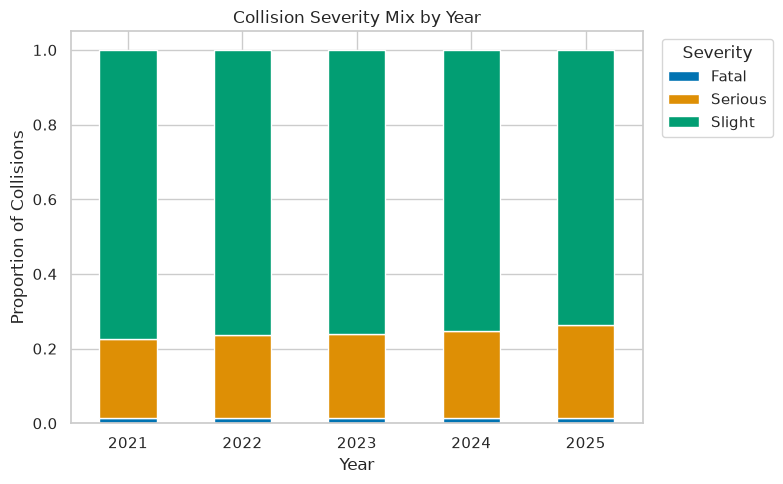

In [19]:
year_props_ordered = year_props[SEVERITY_ORDER].sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
year_props_ordered.plot(
    kind="bar", stacked=True, ax=ax,
    color=[SEVERITY_PALETTE[s] for s in SEVERITY_ORDER],
)
ax.set_title("Collision Severity Mix by Year")
ax.set_xlabel("Year")
ax.set_ylabel("Proportion of Collisions")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title="Severity", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


**Interpretation:** Slight collisions dominate throughout (~74-77% of the
total each year) and the Fatal share is small and essentially flat (~1.4-1.5%
every year). The Serious share, though, drifts gently upward across the
window, from ~21% in 2021 to ~25% in 2025, with Slight correspondingly
shrinking. Since the legacy 3-category severity field is used consistently
across all five years (Decision 10), this drift looks like a real, if modest,
trend rather than an artefact of a classification-scheme change.

### Figure 2 — Severity by speed limit

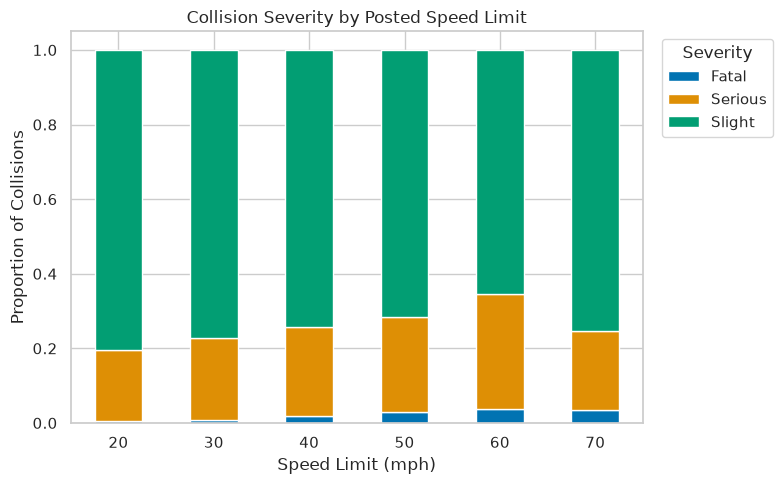

In [20]:
speed_props_ordered = speed_props[SEVERITY_ORDER].sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
speed_props_ordered.plot(
    kind="bar", stacked=True, ax=ax,
    color=[SEVERITY_PALETTE[s] for s in SEVERITY_ORDER],
)
ax.set_title("Collision Severity by Posted Speed Limit")
ax.set_xlabel("Speed Limit (mph)")
ax.set_ylabel("Proportion of Collisions")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title="Severity", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


**Interpretation:** The combined Fatal+Serious share rises steadily with
speed limit from 20mph (~20%) up to 60mph (~34%), the expected pattern of
higher impact speed, worse outcome. But 70mph roads break the trend, dropping
back to ~25%, close to the 40mph level. 70mph limits in Great Britain apply
almost exclusively to motorways and grade-separated dual carriageways, which
have no oncoming traffic, no junctions and controlled access — so despite the
higher speed, the _road environment_ is safer than the single-carriageway
60mph rural roads that make up most of that category. This is a good example
of why speed limit alone is a proxy for road type/environment, not a clean
causal variable on its own.

A shared helper renders the remaining three cyclical breakdowns (hour,
day of week, month) as rose charts — stacked polar bar charts where each
sector is a time unit and the stacked wedge shows that unit's severity
mix.

In [21]:
def plot_severity_rose(counts, category_order, title, tick_labels=None):
    """Plot a stacked polar (rose) bar chart of severity counts.

    Each sector around the circle is one category (e.g. an hour of day).
    Radial wedge length shows collision *volume* for that category, and the
    stacked colour segments within the wedge show the severity *split* for
    it — so both patterns are visible in one chart, rather than only volume
    or only proportions.

    Parameters
    ----------
    counts : pd.DataFrame
        Raw counts table indexed by the cyclical variable, as returned by
        ``severity_breakdown``.
    category_order : list
        Order of categories (index values of ``counts``) around the circle.
    title : str
        Chart title.
    tick_labels : list, optional
        Labels to display at each sector; defaults to ``category_order``.

    Returns
    -------
    matplotlib.figure.Figure
    """
    tick_labels = tick_labels if tick_labels is not None else category_order
    n = len(category_order)
    theta = np.linspace(0, 2 * np.pi, n, endpoint=False)
    width = (2 * np.pi / n) * 0.9

    fig = plt.figure(figsize=(7, 7))
    ax = fig.add_subplot(111, projection="polar")
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)

    bottom = np.zeros(n)
    for severity in SEVERITY_ORDER:
        values = counts.loc[category_order, severity].values
        ax.bar(theta, values, width=width, bottom=bottom, label=severity, color=SEVERITY_PALETTE[severity])
        bottom += values

    ax.set_xticks(theta)
    ax.set_xticklabels(tick_labels)
    ax.set_rlabel_position(-180 / n)  # in the gap between bars, not on top of one
    ax.set_ylabel("Collision Count", labelpad=30)
    ax.set_title(title, pad=20)
    ax.legend(title="Severity", loc="upper left", bbox_to_anchor=(1.1, 1.1))
    return fig


### Figure 3 — Severity by hour of day

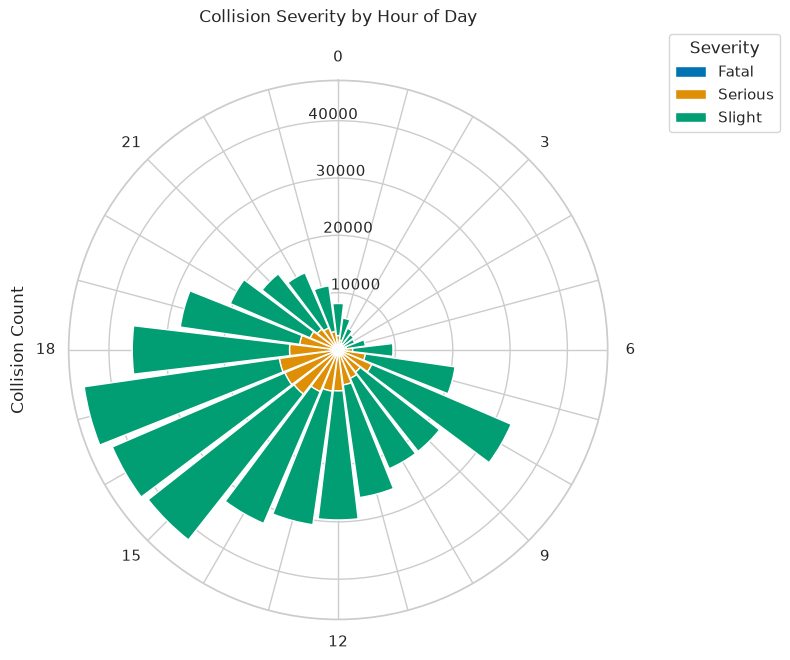

In [22]:
hour_order = list(range(24))
hour_labels = [str(h) if h % 3 == 0 else "" for h in hour_order]
plot_severity_rose(hour_counts, hour_order, "Collision Severity by Hour of Day", hour_labels)
plt.show()


**Interpretation:** Collision volume (wedge length) peaks around the
morning and afternoon commute hours, with a long, thin trough overnight.
Severity mix (colour split within each wedge), however, skews slightly
towards Fatal/Serious in the overnight hours despite the low volume there
consistent with higher average speeds and lower visibility late at night,
even though most collisions happen during the day.

### Figure 4 — Severity by day of week

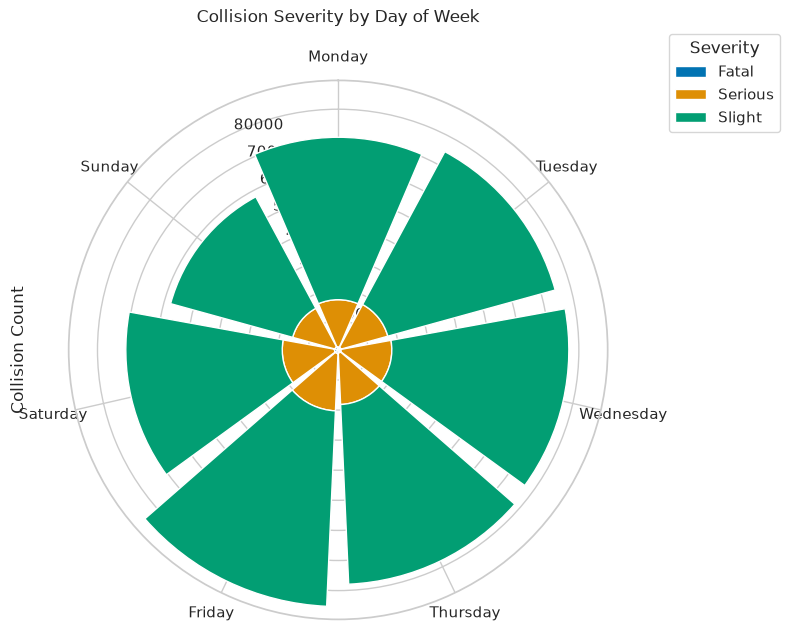

In [23]:
dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
plot_severity_rose(dow_counts, dow_order, "Collision Severity by Day of Week")
plt.show()


**Interpretation:** Collision volume (wedge length) is highest on Friday and
fairly similar across the other weekdays, then falls away on the weekend,
Sunday has the lowest volume of any day. Despite that lower volume, Saturday
and Sunday both show a visibly larger Fatal/Serious slice (~26-27%) than any
weekday (~23-24%). This is consistent with a "fewer but more severe" weekend
pattern, plausibly linked to leisure/night driving rather than commuting.

### Figure 5 — Severity by month

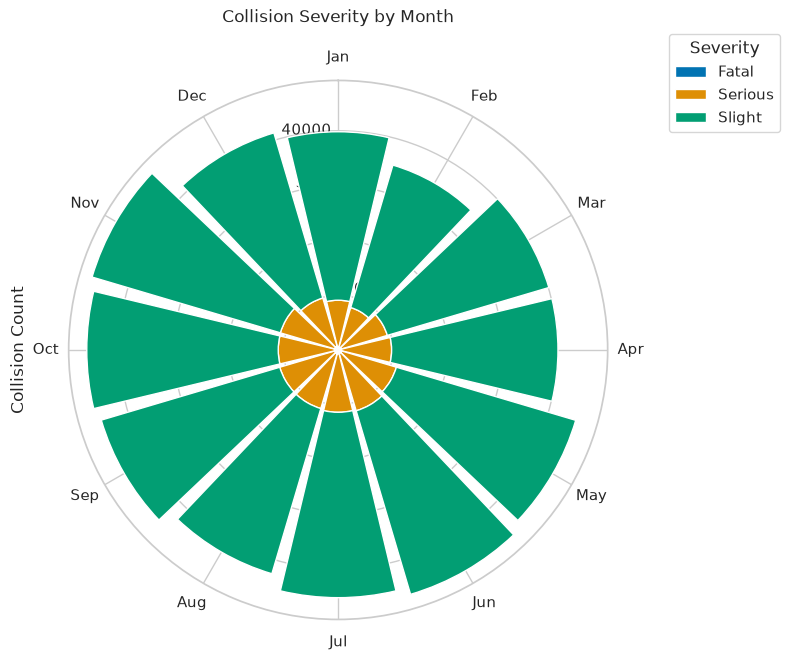

In [24]:
month_order = list(range(1, 13))
month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
plot_severity_rose(month_counts, month_order, "Collision Severity by Month", month_labels)
plt.show()


**Interpretation:** Collision volume is fairly flat across the year (February
is the clear low point, but it's also the shortest month, so that's largely a
day-count effect rather than a seasonal one). The Fatal+Serious share, though,
does show a mild seasonal pattern, it rises through spring to a summer peak
around July-August (~25-26%) before falling back to its lowest point in
January (~23%). That's the opposite of a naive "worse weather = worse
outcomes" story; plausibly it reflects more high-speed rural/leisure driving
in summer months versus more low-speed urban/commute driving in winter.

## Summary & Interpretation

**What was learned.** Across the five-year STATS19 collision extract (2021-2025,
~514k collisions), Slight collisions dominate (roughly three-quarters of the
total) and Fatal collisions are rare (~1.5%), with Serious making up the rest.
The Serious share drifted gently upward over the five years (~21% to ~25%),
while Fatal stayed essentially flat — a modest trend worth watching rather
than a dramatic shift.

**Patterns and insights.** The clearest, most actionable signal is speed
limit: the combined Fatal+Serious share rises steadily from 20mph up to
60mph, roughly doubling. Somewhat surprisingly, it then *drops* at 70mph
rather than continuing to climb. Almost all 70mph roads in Great Britain (Police Service of Northern Ireland do not report here) are
motorways or grade-separated dual carriageways, which lack oncoming traffic
and junctions, so the _road environment_ more than compensates for the higher
speed. This is a good reminder that speed limit is a proxy for road type as
much as it is a measure of speed itself. The cyclical breakdowns tell a
similar "volume vs. risk" story: collision volume peaks during commuting
hours and on Fridays, but the collisions that _do_ happen overnight, and on
weekends (especially Sunday), carry a higher Fatal+Serious share despite
their lower volume. Seasonally, severity share peaks mildly in summer
(June-August) rather than winter, the opposite of a naive "bad weather
means worse outcomes" assumption, plausibly reflecting more high-speed
rural/leisure driving in summer versus more low-speed urban/commute driving
in winter.

**Limitations and assumptions.** This analysis uses only the collision-level
table (Decision 2), there's no exposure/traffic-volume denominator, so
"severity share" measures risk _given a collision happened_, not risk *per
trip or per mile driven*. The DfT's pre-curated "last 5 years" extract was
used as-is (Decision 4), trusting their definition of the window rather than
assembling year files independently. All 44 collision-table columns were
loaded and inspected in Data Ingestion, but the cleaning/EDA/visualization
work below deliberately narrows to just 9 of them (severity, speed limit,
and time fields), so while the *dataset* isn't blind to weather, road
surface, junction detail, etc., *this analysis* is, and those fields likely
confound the speed-limit and time-of-day patterns above (e.g. some of the
"60mph vs 70mph" gap could really be a weather- or junction-type effect
riding along with speed limit). The `-1` sentinel cleaning (Task 3) only
checked those 9 narrowed columns (and only found unknowns in `speed_limit`,
3 rows), that says nothing about missingness in the other 35 fields, which
weren't run through that check.

**What was surprising.** Two findings ran against the naive prior: 70mph
roads being *safer*, proportionally, than 60mph roads; and summer months
showing a *higher* severity share than winter months. Both are explainable
once road type and driving context are considered, but neither would have
been guessed from "higher speed" or "worse weather" reasoning alone: a
useful illustration of why grouped EDA, not intuition, should drive claims
about a dataset like this.